In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier 

In [3]:
import zipfile

zip_path = r"C:\Users\HP\Downloads\NLP\malaria dataset.zip"
extract_path = r"C:\Users\HP\Downloads\NLP\malaria dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
data_dir =  r"C:\Users\HP\Downloads\NLP\malaria dataset"
print(os.listdir(data_dir))

['images', 'SampleSubmission.csv', 'Test.csv', 'Train.csv']


In [7]:
# List the classes
classes = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

data_info = []
for cls in classes:
    path = os.path.join(data_dir, cls)
    count = len(os.listdir(path))
    data_info.append({'Class': cls, 'Count': count})

df_info = pd.DataFrame(data_info)
print(df_info)

    Class  Count
0  images   3925


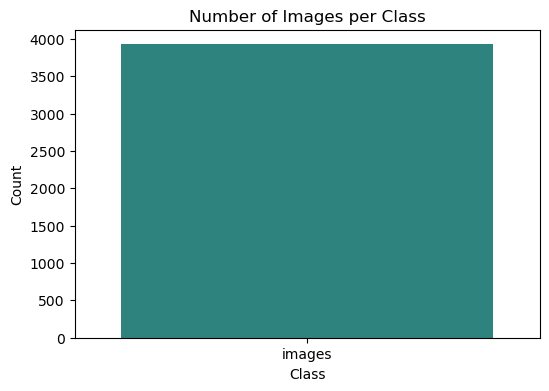

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x='Class',
    y='Count',
    hue='Class',
    data=df_info,
    palette='viridis',
    legend=False
)
plt.title('Number of Images per Class')
plt.show()

In [13]:
import PIL.Image as Image

sample_class = classes[0]
sample_img_name = os.listdir(os.path.join(data_dir, sample_class))[0]
sample_img_path = os.path.join(data_dir, sample_class, sample_img_name)

with Image.open(sample_img_path) as img:
    width, height = img.size
    mode = img.mode  # RGB or L (grayscale)
    
print(f"Sample Image: {sample_img_name}")
print(f"Dimensions: {width}x{height}")
print(f"Color Mode: {mode}")

Sample Image: id_0051lznyrt.jpg
Dimensions: 4032x3016
Color Mode: RGB


In [14]:
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
for cls in classes:
    path = os.path.join(data_dir, cls)
    files = os.listdir(path)
    invalid_files = [f for f in files if not f.lower().endswith(valid_extensions)]
    
    print(f"Class {cls} has {len(invalid_files)} non-image files.")
    if invalid_files:
        print(f"Invalid files found: {invalid_files}")

Class images has 0 non-image files.


In [20]:
import pandas as pd

sample_submission_path = os.path.join(data_dir, 'SampleSubmission.csv')
df_sample = pd.read_csv(sample_submission_path)

print(df_sample.head())

            Image_ID        class  confidence  ymin  xmin  ymax  xmax
0  id_02i83lum2m.jpg          NEG         0.5   100   100   100   100
1  id_02i83lum2m.jpg  Trophozoite         0.5   100   100   100   100
2  id_02i83lum2m.jpg          WBC         0.5   100   100   100   100
3  id_02kpdbnrfn.jpg          NEG         0.5   100   100   100   100
4  id_02kpdbnrfn.jpg  Trophozoite         0.5   100   100   100   100


In [8]:
# Initialize the Generator with a 20% validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load the training data
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Load the test data
test_data = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3140 images belonging to 1 classes.
Found 785 images belonging to 1 classes.


In [15]:
import pandas as pd
import os

# 1. LOAD THE DATA (This defines train_df)
# Make sure the path matches your data_dir from earlier
data_path = r"C:\Users\HP\Downloads\NLP\malaria dataset\Train.csv"
train_df = pd.read_csv(data_path)

# Feature engineering
train_df['width'] = train_df['xmax'] - train_df['xmin']
train_df['height'] = train_df['ymax'] - train_df['ymin']
train_df['area'] = train_df['width'] * train_df['height']

# To calculate centroids
train_df['x_center'] = (train_df['xmin'] + train_df['xmax']) / 2
train_df['y_center'] = (train_df['ymin'] + train_df['ymax']) / 2

#  Density Check: Count objects per image
obj_counts = train_df.groupby('Image_ID')['class'].count().reset_index()
obj_counts.columns = ['Image_ID', 'density']
train_df = train_df.merge(obj_counts, on='Image_ID')

# To preview the data
print("Dataset loaded and features engineered successfully!")
print(train_df[['Image_ID', 'class', 'width', 'height', 'area', 'density']].head(10))

Dataset loaded and features engineered successfully!
            Image_ID        class  width  height   area  density
0  id_u3q6jdck4j.jpg  Trophozoite     29      25    725        4
1  id_a6cl90trri.jpg  Trophozoite     38      42   1596       23
2  id_qvc2le9sm8.jpg  Trophozoite    126     131  16506        6
3  id_w8xnbd5rvm.jpg  Trophozoite     79     116   9164       21
4  id_6dop09rk02.jpg          NEG      0       0      0        1
5  id_i7r9hkhxvx.jpg          WBC     57      57   3249       16
6  id_fzogq9kijh.jpg          WBC     93      70   6510       15
7  id_i8qcpi8ey9.jpg  Trophozoite     29      31    899       12
8  id_y0me081u0v.jpg          NEG      0       0      0        1
9  id_2phbgf1x5m.jpg  Trophozoite     36      38   1368       60


In [18]:
import tensorflow as tf
IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess_image(image_id, data_dir):
    img_path = data_dir + "/" + image_id
    
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    
    return img

In [19]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

def build_google_standard_model(num_classes):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    base_model.trainable = False 
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), 
        layers.BatchNormalization(),     
        layers.Dropout(0.2),            
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_google_standard_model(num_classes=3)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,534 (15.48 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [20]:
# Calculate the center points of the parasites
# This helps in counting and distance-based analysis
train_df['x_center'] = (train_df['xmin'] + train_df['xmax']) / 2
train_df['y_center'] = (train_df['ymin'] + train_df['ymax']) / 2

# Inspecting the new "Tesla-style" spatial features
print(train_df[['Image_ID', 'class', 'x_center', 'y_center']].head())

            Image_ID        class  x_center  y_center
0  id_u3q6jdck4j.jpg  Trophozoite    1255.5     724.5
1  id_a6cl90trri.jpg  Trophozoite    1585.0     579.0
2  id_qvc2le9sm8.jpg  Trophozoite    2851.0    1382.5
3  id_w8xnbd5rvm.jpg  Trophozoite    1783.5     983.0
4  id_6dop09rk02.jpg          NEG       0.0       0.0


In [21]:
# Data augmentation
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

In [23]:
from tensorflow.keras import layers, models

# Using The Image Features (EfficientNet)
image_input = layers.Input(shape=(224, 224, 3), name='image_input')
base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet')(image_input)
img_features = layers.GlobalAveragePooling2D()(base_model)

# Using Spatial Features (Centroids, Area, Aspect Ratio)
spatial_input = layers.Input(shape=(5,), name='spatial_input') 
spatial_features = layers.Dense(16, activation='relu')(spatial_input)

# Merging the two branches
merged = layers.Concatenate()([img_features, spatial_features])

x = layers.Dense(64, activation='relu')(merged)
output = layers.Dense(3, activation='softmax', name='class_output')(x) 
model = models.Model(inputs=[image_input, spatial_input], outputs=output)
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
print("Model built and connected successfully!")

Model built and connected successfully!


In [1]:
import os
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split


data_csv_path = r"C:\Users\HP\Downloads\NLP\malaria dataset\Train.csv"
image_folder_path = r"C:\Users\HP\Downloads\NLP\malaria dataset\images"

train_df = pd.read_csv(data_csv_path)

# Engineering spatial logic features
train_df['width'] = train_df['xmax'] - train_df['xmin']
train_df['height'] = train_df['ymax'] - train_df['ymin']
train_df['area'] = train_df['width'] * train_df['height']
train_df['x_center'] = (train_df['xmin'] + train_df['xmax']) / 2
train_df['y_center'] = (train_df['ymin'] + train_df['ymax']) / 2

In [34]:
# 2. SPLIT DATA 
unique_images = train_df['Image_ID'].unique().tolist() 

train_ids, val_ids = train_test_split(unique_images, test_size=0.2, random_state=42)
train_set = train_df[train_df['Image_ID'].isin(train_ids)]
val_set = train_df[train_df['Image_ID'].isin(val_ids)]

print(f"Split successful!")
print(f"Training images: {len(train_ids)} | Validation images: {len(val_ids)}")

Split successful!
Training images: 2197 | Validation images: 550


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

data_csv_path = r"C:\Users\HP\Downloads\NLP\malaria dataset\Train.csv"
train_df = pd.read_csv(data_csv_path)

# 2. Re-apply the Feature Engineering (Centroids, etc.)
train_df['width'] = train_df['xmax'] - train_df['xmin']
train_df['height'] = train_df['ymax'] - train_df['ymin']
train_df['area'] = train_df['width'] * train_df['height']
train_df['x_center'] = (train_df['xmin'] + train_df['xmax']) / 2
train_df['y_center'] = (train_df['ymin'] + train_df['ymax']) / 2

unique_images = train_df['Image_ID'].unique().tolist()
train_ids, val_ids = train_test_split(unique_images, test_size=0.2, random_state=42)

train_set = train_df[train_df['Image_ID'].isin(train_ids)]
val_set = train_df[train_df['Image_ID'].isin(val_ids)]

print(f"Success! train_set defined with {len(train_set)} rows.")

Success! train_set defined with 19009 rows.


In [10]:
image_folder_path = r"C:\Users\HP\Downloads\NLP\malaria dataset\images"

train_gen = MalariaHybridGenerator(train_set, image_folder_path, batch_size=32)
val_gen = MalariaHybridGenerator(val_set, image_folder_path, batch_size=32)

print("Generators are now ready!")

Generators are now ready!


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

image_input = layers.Input(shape=(224, 224, 3), name='image_input')
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=image_input)
base_model.trainable = False 
img_features = layers.GlobalAveragePooling2D()(base_model.output)

spatial_input = layers.Input(shape=(5,), name='spatial_input')
spatial_features = layers.Dense(16, activation='relu')(spatial_input)

merged = layers.Concatenate()([img_features, spatial_features])
x = layers.Dense(64, activation='relu')(merged)
output = layers.Dense(3, activation='softmax', name='class_output')(x)

model = models.Model(inputs=[image_input, spatial_input], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model is re-defined and ready!")

Model is re-defined and ready!


In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
]

In [37]:
from tensorflow.keras.utils import Sequence
import numpy as np
import cv2
import os

class MalariaHybridGenerator(Sequence):
    def __init__(self, df, image_dir, batch_size=32, img_size=(224, 224), shuffle=True, **kwargs):
        # This line fixes the UserWarning
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.class_map = {'Trophozoite': 0, 'WBC': 1, 'NEG': 2}
        self.on_epoch_end()

    def __len__(self):
        # The typo 'ze' was removed from this line
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch_df = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]
        X_img, X_spatial, y = [], [], []

        for _, row in batch_df.iterrows():
            img_path = os.path.join(self.image_dir, row['Image_ID'])
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, self.img_size) / 255.0
                X_img.append(img)
                X_spatial.append([row['x_center'], row['y_center'], row['width'], row['height'], row['area']])
                y.append(self.class_map[row['class']])

        return (np.array(X_img), np.array(X_spatial)), np.array(y)

# Re-initialize with the fixed class
train_gen = MalariaHybridGenerator(train_set, image_folder_path, batch_size=32)
val_gen = MalariaHybridGenerator(val_set, image_folder_path, batch_size=32)

print("Generator fixed and typo removed!")

Generator fixed and typo removed!


In [38]:
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Concatenate
from tensorflow.keras.models import Model

img_input = Input(shape=(224, 224, 3), name='image_input')
x1 = Conv2D(32, (3, 3), activation='relu')(img_input)
x1 = Flatten()(x1)

spatial_input = Input(shape=(5,), name='spatial_input')
x2 = Dense(16, activation='relu')(spatial_input)

merged = Concatenate()([x1, x2])
output = Dense(3, activation='softmax')(merged)

model = Model(inputs=[img_input, spatial_input], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [39]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
594/594 ━━━━━━━━━━━━━━━━━━━━ 1325s 2s/step - accuracy: 0.9097 - loss: 0.9420 - val_accuracy: 0.9344 - val_loss: 1.0356 - learning_rate: 0.0010
Epoch 2/25
594/594 ━━━━━━━━━━━━━━━━━━━━ 1264s 2s/step - accuracy: 0.9566 - loss: 0.3011 - val_accuracy: 0.9244 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 3/25
594/594 ━━━━━━━━━━━━━━━━━━━━ 1293s 2s/step - accuracy: 0.9515 - loss: 0.4001 - val_accuracy: 0.9557 - val_loss: 0.3631 - learning_rate: 0.0010
Epoch 4/25
594/594 ━━━━━━━━━━━━━━━━━━━━ 1979s 3s/step - accuracy: 0.9688 - loss: 0.2059 - val_accuracy: 0.9419 - val_loss: 0.3888 - learning_rate: 0.0010
Epoch 5/25
 81/594 ━━━━━━━━━━━━━━━━━━━━ 26:21 3s/step - accuracy: 0.9643 - loss: 0.3028

KeyboardInterrupt: 

In [41]:
# Evaluate the model on the validation generator
val_loss, val_acc = model.evaluate(val_gen)

print(f"\nFinal Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

141/141 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.9745 - loss: 0.1399

Final Validation Loss: 0.1399
Final Validation Accuracy: 0.9745


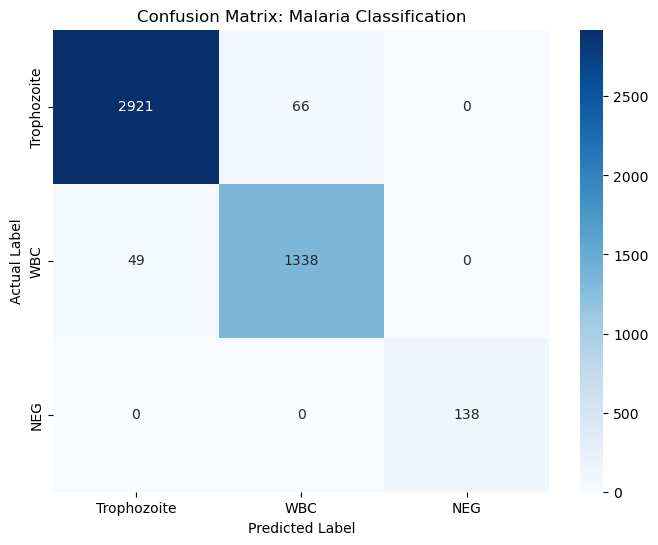

              precision    recall  f1-score   support

 Trophozoite       0.98      0.98      0.98      2987
         WBC       0.95      0.96      0.96      1387
         NEG       1.00      1.00      1.00       138

    accuracy                           0.97      4512
   macro avg       0.98      0.98      0.98      4512
weighted avg       0.97      0.97      0.97      4512



In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

all_labels = []
all_preds = []
for i in range(len(val_gen)):
    x_val, y_val = val_gen[i]
    preds = model.predict(x_val, verbose=0)
    all_labels.extend(y_val)
    all_preds.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(all_labels, all_preds)
class_names = ['Trophozoite', 'WBC', 'NEG']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Malaria Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

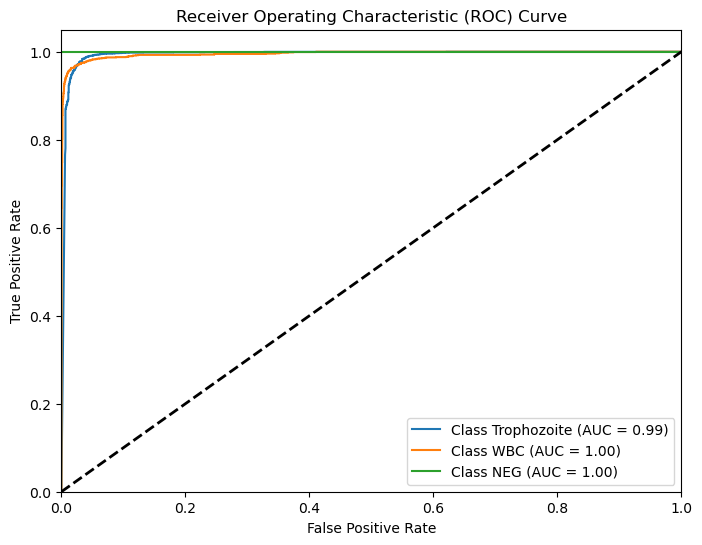

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
y_val_bin = label_binarize(all_labels, classes=[0, 1, 2])
n_classes = 3

all_probs = []
for i in range(len(val_gen)):
    x_val, _ = val_gen[i]
    probs = model.predict(x_val, verbose=0)
    all_probs.extend(probs)
all_probs = np.array(all_probs)

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Gathering predictions from validation set...


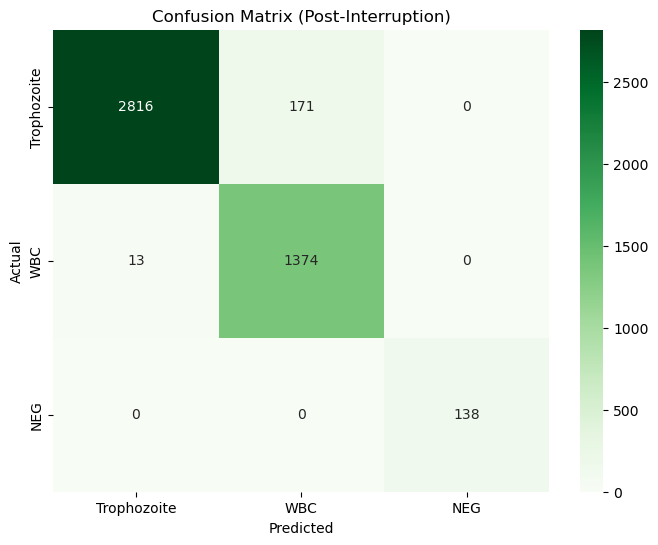

              precision    recall  f1-score   support

 Trophozoite       1.00      0.94      0.97      2987
         WBC       0.89      0.99      0.94      1387
         NEG       1.00      1.00      1.00       138

    accuracy                           0.96      4512
   macro avg       0.96      0.98      0.97      4512
weighted avg       0.96      0.96      0.96      4512



In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Collect predictions
all_labels = []
all_preds = []

print("Gathering predictions from validation set...")
for i in range(len(val_gen)):
    x_val, y_val = val_gen[i]
    preds = model.predict(x_val, verbose=0)
    all_labels.extend(y_val)
    all_preds.extend(np.argmax(preds, axis=1))

# 2. Create Plot
class_names = ['Trophozoite', 'WBC', 'NEG']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Post-Interruption)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [46]:
try:
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=25,
        callbacks=callbacks
    )
except KeyboardInterrupt:
    print("Training interrupted manually. 'history' might be incomplete, but the model is preserved.")
    

Epoch 1/25
Training interrupted manually. 'history' might be incomplete, but the model is preserved.loss: 0.1124    


In [53]:
model.save('malaria_hybrid_model.keras')
print("Model saved to disk!")

Model saved to disk!
